Dataset: Gapminder (Data GDP, Harapan Hidup, dan Populasi berbagai negara).

### Tugas 1. Persiapan dan Loading Data
Mahasiswa akan berhadapan dengan dataset yang memiliki banyak kolom dan tipe data berbeda.

In [8]:
# !pip install plotly

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# Menggunakan dataset gapminder
df = px.data.gapminder()
print(df.info())
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   str    
 1   continent  1704 non-null   str    
 2   year       1704 non-null   int64  
 3   lifeExp    1704 non-null   float64
 4   pop        1704 non-null   int64  
 5   gdpPercap  1704 non-null   float64
 6   iso_alpha  1704 non-null   str    
 7   iso_num    1704 non-null   int64  
dtypes: float64(2), int64(3), str(3)
memory usage: 106.6 KB
None


,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG,4
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG,4
3,Afghanistan,Asia,1967,34.020,11537966,836.197138,AFG,4
4,Afghanistan,Asia,1972,36.088,13079460,739.981106,AFG,4


### Tugas 1: Abstraksi Data (Analitik)

Sebelum memvisualisasikan, mahasiswa wajib membuat tabel abstraksi di dalam Markdown Jupyter Notebook mereka:

|Atribut    | Tipe Atribut  | Ordering Direction    | Keterangan        |
|-----      | -----         | -----                 | -----             |
|country    |Categorical    | N/A                   | Identitas negara  |
|year       |Quantitative   | Sequential/Cyclic     | Waktu (Interval)  |
|lifeExp    |Quantitative   | Sequential            | Angka harapan hidup   |
|gdpPercap  |Quantitative   | Sequential            | Kemakmuran ekonomi    |

### Tugas 2: Visualisasi Hubungan Kompleks
Mahasiswa diminta untuk menggabungkan 4 atribut dalam satu grafik (Bubble Chart).

- X: GDP per Capita (Quantitative)
- Y: Life Expectancy (Quantitative)
- Size: Population (Quantitative)
- Color: Continent (Categorical/Nominal)

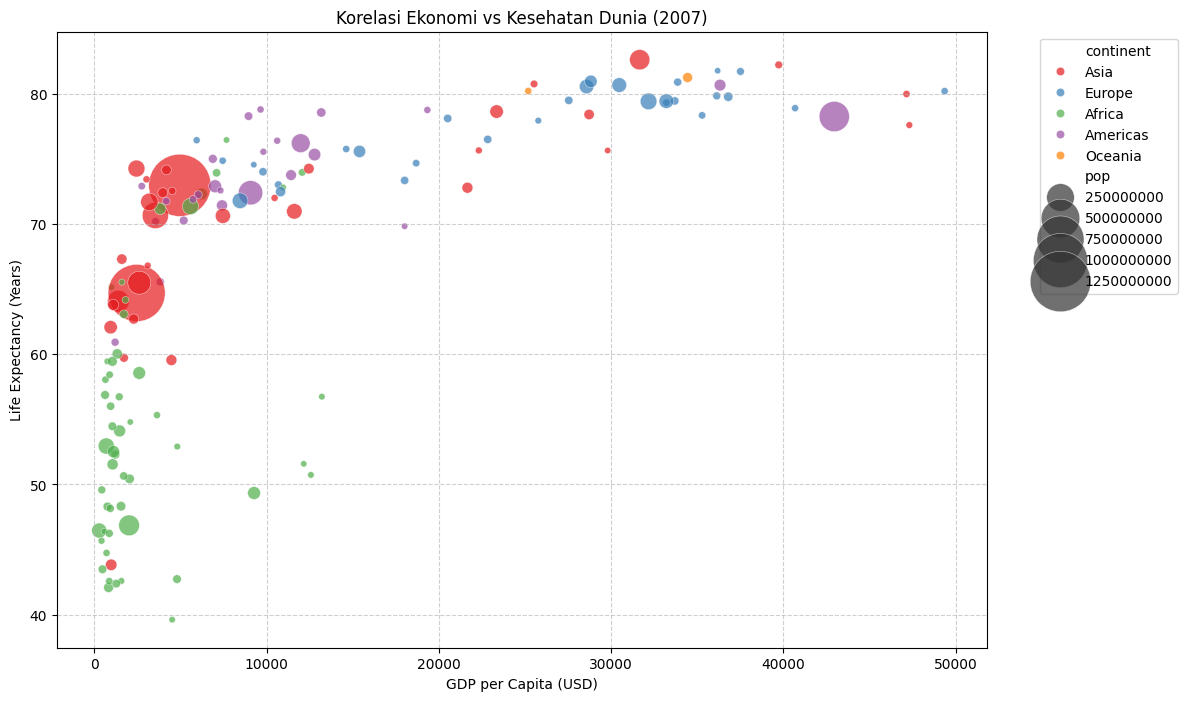

In [6]:
# Mengambil data tahun terbaru (2007)
df_2007 = df[df['year'] == 2007]

plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_2007, x='gdpPercap', y='lifeExp', 
                size='pop', hue='continent', 
                sizes=(20, 2000), alpha=0.7, palette='Set1')

plt.title('Korelasi Ekonomi vs Kesehatan Dunia (2007)')
plt.xlabel('GDP per Capita (USD)')
plt.ylabel('Life Expectancy (Years)')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Tugas 3: Implementasi Diverging Scale (Analisis Pertumbuhan)
mahasiswa harus menghitung selisih (delta) harapan hidup dari tahun 1952 ke 2007 untuk melihat negara mana yang mengalami kemajuan atau kemunduran. 

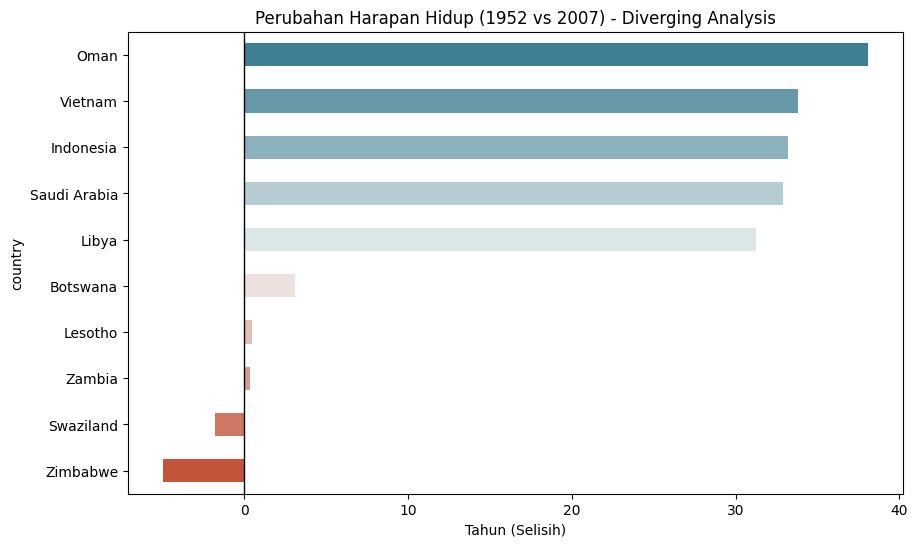

In [7]:
# Pivot data untuk menghitung perubahan
df_pivot = df.pivot(index='country', columns='year', values='lifeExp')
df_pivot['diff'] = df_pivot[2007] - df_pivot[1952]

# Ambil 10 negara dengan perubahan terbesar (positif & negatif)
top_bottom = pd.concat([df_pivot.nlargest(5, 'diff'), df_pivot.nsmallest(5, 'diff')])

# Visualisasi Diverging
plt.figure(figsize=(10, 6))
colors = sns.diverging_palette(20, 220, as_cmap=False, n=len(top_bottom))
top_bottom['diff'].sort_values().plot(kind='barh', color=colors)

plt.axvline(0, color='black', lw=1)
plt.title('Perubahan Harapan Hidup (1952 vs 2007) - Diverging Analysis')
plt.xlabel('Tahun (Selisih)')
plt.show()

### Tugas 4: Evaluasi 
Mahasiswa menjawab pertanyaan kritis ini di akhir laporan
1. Analisis Skala: "Pada Tugas 3, mengapa kita menggunakan skala Diverging bukan Sequential? Apa yang menjadi titik nolnya?"
2. Efektivitas Visual: "Pada Bubble Chart (Tugas 2), atribut mana yang paling sulit dibedakan oleh mata? (Size, Color, atau Position?)"
3. Abstraksi: "Jika saya mengubah year dari angka menjadi kategori (Lama vs Baru), bagaimana tipe atributnya berubah?"

### 5. Tugas Praktikum
1. Lakukan proses 1-4 pada data yang berbeda.
2. Lakukan pemilihan skala dan visual yang tepat terkait dengan skala diverging ataupun sequential